> This script is deigned to be used with conda env
> crime_weather_env

Code to explore the crimetology_NS.parquet file.
Data created via combine_crime_ceda_data.py.

## Import modules

In [1]:
from matplotlib.figure import Figure
from matplotlib.axes._axes import Axes
from pandas.core.frame import DataFrame
from _duckdb import DuckDBPyConnection
import os
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import plotly.express as px

## Directories, db and Path Setup

In [2]:

cwd: str = os.getcwd()
data_dir: Path = Path(cwd) / "data" 
crime_weather_pq: str = "crimetology_NS.parquet"

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=data_dir/":memory")

## Introspect

In [4]:

# introspect (looks like duckdb parquet requires relative paths)
file_path: str = os.path.relpath(path=data_dir.joinpath(crime_weather_pq))
query_introspect: str = f"""DESCRIBE SELECT * 
                            FROM read_parquet(["{file_path}",])
                        """ 
con.execute(query=query_introspect).df()

,column_name,column_type,null,key,default,extra
0,Crime ID,VARCHAR,YES,None,None,None
1,Month,VARCHAR,YES,None,None,None
2,Longitude,DOUBLE,YES,None,None,None
3,Latitude,DOUBLE,YES,None,None,None
4,Crime type,VARCHAR,YES,None,None,None
5,tasmax,FLOAT,YES,None,None,None
6,tas,FLOAT,YES,None,None,None
7,groundfrost,FLOAT,YES,None,None,None
8,sun,FLOAT,YES,None,None,None
9,snowLying,FLOAT,YES,None,None,None


In [5]:
# Crimes present
query_crimes_present: str = f"""SELECT DISTINCT "Crime type"
                               FROM read_parquet(["{file_path}",])
                            """
con.execute(query=query_crimes_present).df()

,Crime type
0,Violence and sexual offences
1,Theft from the person
2,Drugs
3,Shoplifting
4,Robbery
5,Bicycle theft
6,Public order
7,Vehicle crime
8,Other theft
9,Possession of weapons


In [6]:
# head
query_head: str = f"""SELECT *
                       FROM read_parquet(["{file_path}",])
                       LIMIT 5
                       """
con.execute(query_head).df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347


## Data Quality Checks - CrimeID

In [7]:
# syntheic Crime IDs? (Data Quality check)
query_syn: str = f"""SELECT COUNT(*),
                       FROM read_parquet(["{file_path}",])
                       WHERE starts_with("CRIME ID", 'NO_ID_')
                       """
con.execute(query_syn).df()
# Total all time: 207208

,count_star()
0,207208


In [8]:
query_all: str = f"""SELECT COUNT(*)
                       FROM read_parquet(["{file_path}",])
                       """
con.execute(query_all).df()
# 1280212

,count_star()
0,1280212


In [9]:
207208/1280212

0.16185444285790165

SO total percentage of rows with a synthetic ID is ~ 16%

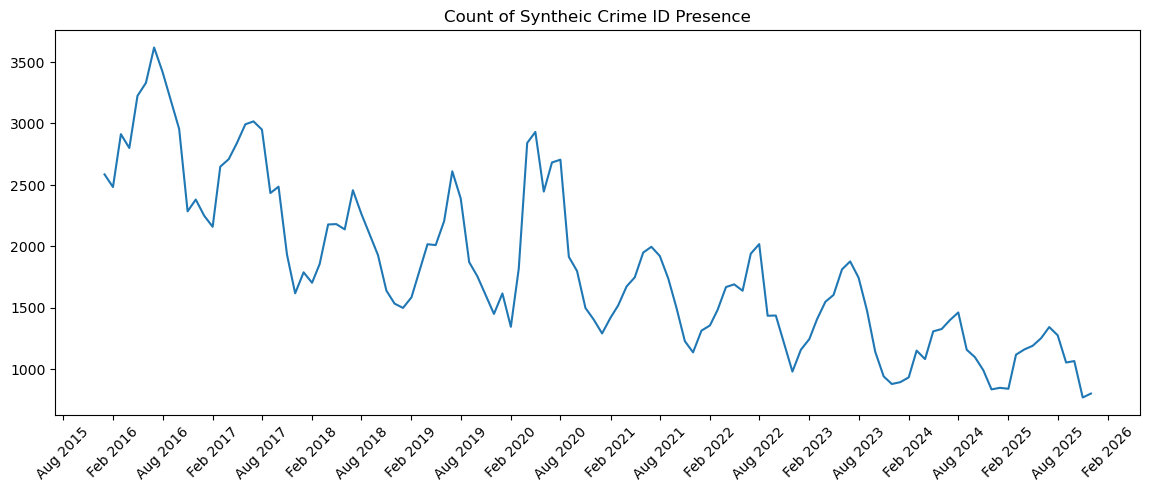

In [10]:
# is this changing over time?
query_syn: str = f"""SELECT COUNT(*) AS COUNT,
                            "Month"
                       FROM read_parquet(["{file_path}",])
                       WHERE starts_with("CRIME ID", 'NO_ID_')
                       GROUP BY "Month"
                       ORDER BY "Month"
                       """
df: DataFrame = con.execute(query_syn).df()

## quick plot
df['Month'] = pd.to_datetime(arg=df['Month'])
fig,ax= plt.subplots(nrows=1,ncols=1,figsize=(14,5))

ax.xaxis.set_major_locator(locator=mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(formatter=mdates.DateFormatter(fmt='%b %Y'))

plt.xticks(rotation=45)
plt.title(label='Count of Syntheic Crime ID Presence')

ax.plot(df['Month'],df['COUNT'])
plt.show()


Question - should this be dropped? Appears to be seasonality and trend in this. It could be some seaonal crime less likely to be assigned a crimeid? OR peaks in systematic demand with data being corrected and updated later in the year?

## Geography Check

In [11]:
lat_lon_query: str = f"""SELECT DISTINCT "Latitude",
                                         "Longitude"
                         FROM read_parquet(["{file_path}",])
                       """
lat_lons_df: DataFrame = con.execute(lat_lon_query).df()

Note: this needs the VSCode extension Jupyter Notebook Renderers (Microsoft) to plot

In [16]:

fig = px.scatter_map(data_frame=lat_lons_df,
                lat='Latitude',
                lon='Longitude')
fig.update_layout(mapbox_style="open-street-map")
#fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

So, obviously filtereing by *WHERE "Falls within" IN ('Norfolk Constabulary', 'Suffolk Constabulary')* in combine_crime_ceda_data.py has not limited the geographic domain enough. 
Checking the [archives info page](https://data.police.uk/about/) - this pulls data that was provided by the respective constabularies, not necessarily where it happened. 


|Field   |   Meaning |
| ------ | --------- |
| Falls within	| At present, also the force that provided the data about the crime. This is currently being looked into and is likely to change in the near future.| 

Currently my course of action is to clip via min max lat lons, to get the project underway. Future improvement should be masking the data properly, or updating the pipeline updating so it maps the lat/lon on the 1km grid to a County and then filters by that.